# 02 — Preparação dos dados para o modelo

Depois de conhecer os dados ([`01_exploracao.ipynb`](01_exploracao.ipynb)), o próximo passo é deixá-los **prontos para o treino**.
Toda a lógica fica em [`src/features.py`](../src/features.py), para ser reaproveitada pelo script de treino e pelo app — este notebook só **mostra e confere** o resultado.

O que a preparação faz:

| Etapa | Por quê |
|---|---|
| Remove `UDI` e `Product ID` | São só identificadores; não descrevem o estado da máquina. |
| Remove `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | **Vazamento de alvo**: dizem qual falha aconteceu, informação que só existe depois da quebra. |
| Alvo = `Machine failure` | 1 = falhou, 0 = não falhou. |
| Cria `power_w` | Potência mecânica no eixo: torque [Nm] × rotação [rpm] × 2π/60. |
| Cria `temp_diff_k` | Temperatura de processo − temperatura do ar: indica se o calor está sendo dissipado. |
| Codifica `Type` | L → 0, M → 1, H → 2 (codificação ordinal, pois existe ordem de qualidade). |
| Limpa nomes das colunas | `Air temperature [K]` → `air_temperature_k` (o XGBoost não aceita colchetes). |
| Divide treino/teste 80/20 | **Estratificado** pelo alvo, `random_state=42`, para reprodutibilidade. |

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data import load_data
from src.features import (FAILURE_MODE_COLUMNS, ID_COLUMNS, TYPE_MAPPING,
                          get_train_test, prepare_features, save_processed)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 2)

## 1. Do dado bruto às variáveis do modelo

In [2]:
df_raw = load_data()
X, y = prepare_features(df_raw)

print("Colunas originais :", list(df_raw.columns))
print("Colunas removidas :", ID_COLUMNS + FAILURE_MODE_COLUMNS)
print("Features do modelo:", list(X.columns))
print("Codificação de Type:", TYPE_MAPPING)
print(f"X: {X.shape[0]} linhas x {X.shape[1]} colunas | y: {y.name}")
X.head()

[dados] CSV já existe em data/raw/ai4i2020.csv — download ignorado.
Colunas originais : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Colunas removidas : ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Features do modelo: ['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'power_w', 'temp_diff_k']
Codificação de Type: {'L': 0, 'M': 1, 'H': 2}
X: 10000 linhas x 8 colunas | y: machine_failure


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,power_w,temp_diff_k
0,1,298.1,308.6,1551,42.8,0,6951.59,10.5
1,0,298.2,308.7,1408,46.3,3,6826.72,10.5
2,0,298.1,308.5,1498,49.4,5,7749.39,10.4
3,0,298.2,308.6,1433,39.5,7,5927.50,10.4
4,0,298.2,308.7,1408,40.0,9,5897.82,10.5


### Conferência anti-vazamento

Um teste simples e explícito: nenhuma das colunas de modo de falha (nem o próprio alvo) pode estar entre as variáveis de entrada.

In [3]:
proibidas = {"twf", "hdf", "pwf", "osf", "rnf", "machine_failure",
             "TWF", "HDF", "PWF", "OSF", "RNF", "Machine failure"}
presentes = proibidas & set(X.columns)
assert not presentes, f"Vazamento! Colunas proibidas em X: {presentes}"
print("OK: nenhuma coluna de modo de falha ou do alvo está nas features.")
print("Tipos das features:")
X.dtypes

OK: nenhuma coluna de modo de falha ou do alvo está nas features.
Tipos das features:


type                       int64
air_temperature_k        float64
process_temperature_k    float64
rotational_speed_rpm       int64
torque_nm                float64
tool_wear_min              int64
power_w                  float64
temp_diff_k              float64
dtype: object

## 2. As novas variáveis físicas

`power_w` junta torque e rotação numa grandeza só (a potência que a máquina entrega), e `temp_diff_k` resume as duas temperaturas.
Para quem vem da manutenção, são exatamente as grandezas que a gente olharia num painel: **"a máquina está trabalhando fora da faixa de potência?"** e **"o calor está saindo?"**.

,power_w,temp_diff_k
machine_failure,,
Mediana sem falha,6243.05,9.8
Mediana com falha,7611.43,9.3


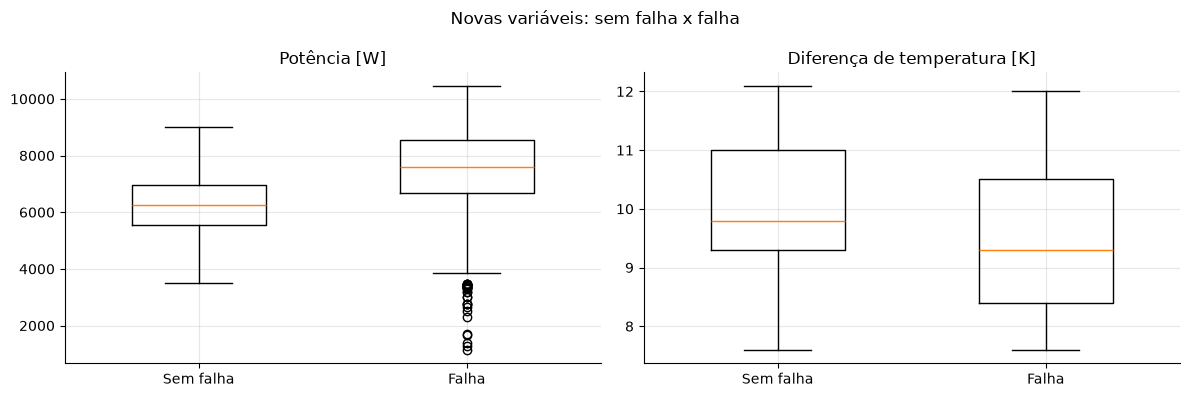

In [4]:
novas = X[["power_w", "temp_diff_k"]].assign(machine_failure=y)
display(novas.groupby("machine_failure").median().rename(index={0: "Mediana sem falha", 1: "Mediana com falha"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, titulo in [(axes[0], "power_w", "Potência [W]"), (axes[1], "temp_diff_k", "Diferença de temperatura [K]")]:
    ax.boxplot([X.loc[y == 0, col], X.loc[y == 1, col]], widths=0.5)
    ax.set_xticks([1, 2], ["Sem falha", "Falha"])
    ax.set_title(titulo)
plt.suptitle("Novas variáveis: sem falha x falha")
plt.tight_layout()
plt.show()

Nas falhas, a potência mediana é maior e a diferença de temperatura mediana é menor (pior dissipação de calor) — as duas variáveis carregam sinal útil para o modelo.

## 3. Divisão treino/teste estratificada

A função `get_train_test()` é a mesma que o treino vai usar. Com a estratificação, a proporção de falhas deve ficar praticamente igual nos dois conjuntos.

In [5]:
X_train, X_test, y_train, y_test = get_train_test(df_raw)

balanco = pd.DataFrame({
    "linhas": [len(y), len(y_train), len(y_test)],
    "falhas": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
    "sem_falha": [int((y == 0).sum()), int((y_train == 0).sum()), int((y_test == 0).sum())],
    "taxa_falha (%)": [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
}, index=["Total", "Treino (80%)", "Teste (20%)"])
balanco["taxa_falha (%)"] = balanco["taxa_falha (%)"].round(2)
balanco

,linhas,falhas,sem_falha,taxa_falha (%)
Total,10000,339,9661,3.39
Treino (80%),8000,271,7729,3.39
Teste (20%),2000,68,1932,3.40


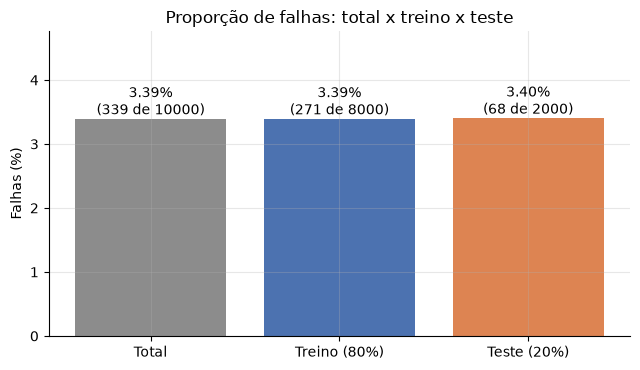

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
barras = ax.bar(balanco.index, balanco["taxa_falha (%)"], color=["#8C8C8C", "#4C72B0", "#DD8452"])
for b, (_, linha) in zip(barras, balanco.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, linha["taxa_falha (%)"],
            f"{linha['taxa_falha (%)']:.2f}%\n({int(linha['falhas'])} de {int(linha['linhas'])})",
            ha="center", va="bottom")
ax.set_ylim(0, balanco["taxa_falha (%)"].max() * 1.4)
ax.set_ylabel("Falhas (%)")
ax.set_title("Proporção de falhas: total x treino x teste")
plt.tight_layout()
plt.show()

A proporção de falhas é praticamente a mesma no total, no treino e no teste — a estratificação funcionou.
O conjunto de teste fica **separado** e só será usado no fim, para medir o desempenho do modelo de forma honesta.

## 4. Salvando os dados preparados

Os arquivos vão para `data/processed/` (fora do Git). O mesmo resultado é gerado pela linha de comando com `python -m src.features`.

In [7]:
save_processed(X_train, X_test, y_train, y_test)
for arq in sorted((ROOT / "data" / "processed").glob("*.csv")):
    print(f"{arq.relative_to(ROOT)}  ({arq.stat().st_size / 1024:.0f} KB)")

data/processed/X_test.csv  (78 KB)
data/processed/X_train.csv  (311 KB)
data/processed/y_test.csv  (4 KB)
data/processed/y_train.csv  (16 KB)


## Resumo

- **8 features** de entrada: tipo do produto, duas temperaturas, rotação, torque, desgaste da ferramenta, potência e diferença de temperatura.
- **Sem vazamento**: modos de falha e identificadores ficaram de fora (conferido por `assert`).
- **Treino: 8.000 registros (271 falhas, 3,39%) · Teste: 2.000 registros (68 falhas, 3,40%).**

**Próximo passo:** treinar o modelo XGBoost e explicar as previsões com SHAP.